## Save Pickle

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
from torch.utils.data import DataLoader
from boilerplate.dataloader import SemisupervisedDataset
from tqdm import tqdm
import tifffile as tiff
import torch
import torch.nn.functional as F
import pandas as pd
from numpy.linalg import norm
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [ ]:
best_checkpoint = "/group/jug/Sheida/HVAE/segmentation/test/model_supervised/segmentation_best_vae.net"
patch_size = 64
label_size = 1
mode = 'semisupervised'
n_classes = 4
batch_size = 1

In [ ]:
data_dir = "/group/jug/Sheida/pancreatic beta cells/download/"
keys = ["high_c1", "high_c2", "high_c3"]

img_paths = [os.path.join(data_dir + key + f"/{key}_source.tif") for key in keys]
lbl_paths = [os.path.join(data_dir + key + f"/{key}_gt.tif") for key in keys]
imgs = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, img_paths)}
lbls = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, lbl_paths)}
train_idx = {}
np.random.seed(42)
for key in keys:
    # Create a mask for valid indices where labels are not all -1
    # -1 indicates outside of the cell
    
    valid_indices = np.where(~np.all(lbls[key] == -1, axis=(1, 2)))[0]
    total_samples = valid_indices.shape[0]
    np.random.shuffle(valid_indices)  # Shuffles in place

    # Compute split index
    split_idx = int(0.85 * total_samples)

    # Split the indices
    train_idx[key] = valid_indices[:split_idx]

# compute mean and std of the data
all_elements = np.concatenate([imgs[key][train_idx[key]].flatten() for key in keys])
data_mean = np.mean(all_elements)
data_std = np.std(all_elements.astype(np.float32))

# normalizing the data
for key in tqdm(keys, "Normalizing data"):
    imgs[key] = (imgs[key] - data_mean) / data_std

train_set = SemisupervisedDataset(
    images=imgs,
    labels=lbls,
    patch_size=patch_size,
    label_size=label_size,
    mode=mode,
    n_classes=n_classes,
    ignore_lbl=-1,
    indices_dict=train_idx,
)

In [ ]:
model = torch.load(best_checkpoint, weights_only=False)
model.update_mode(mode)
model.eval()

for patch in tqdm(DataLoader(train_set, batch_size=batch_size), desc="Evaluating on training set"):
    labels = patch[1].view(-1,1).squeeze(-1).to(device)
    patch = patch[0].float().squeeze(0).to(device)
    with torch.no_grad():
        output = model(patch, labels)
        
        break

In [ ]:
output.keys()

In [ ]:
output['pi'].shape

In [ ]:
type(output['mu'])

In [ ]:
output['mu'][0].shape, output['mu'][1].shape, output['mu'][2].shape

In [ ]:
all_rows = []

for anchor_id, batch in tqdm(enumerate(DataLoader(train_set, batch_size=batch_size)), desc="Evaluating on training set"):

    group = train_set.groups[anchor_id]  # dict with keys: name, z, coords, labels
    name   = group['name']
    z_idx  = group['z']
    coords = group['coords']   # list of 8 (y,x)
    group_labels = group['labels']   # list of 8

    
    labels = batch[1].view(-1,1).squeeze(-1).to(device)
    batch = batch[0].float().squeeze(0).to(device)
    with torch.no_grad():
        
        output = model(batch, labels)

        pi = output['pi']               # (8,4)
        mus = output['mu']             # list of 3 tensors
        z   = torch.cat(
                [F.adaptive_avg_pool2d(x, (1,1)).flatten(1) for x in mus],
                dim=1
            )                          # (8,latent_dim)
        z   = F.normalize(z, dim=1)

        for n in range(8):
            row = {
                'anchor_id': anchor_id,
                'name'     : name,
                'z'        : z_idx,
                'y'        : coords[n][0],
                'x'        : coords[n][1],
                'label'    : group_labels[n],
                'neighbor_index': n,
                'pi'       : pi[n].detach().cpu().numpy(),    # (4,)
                'latent'        : z[n].detach().cpu().numpy(),     # (latent,)
            }
            all_rows.append(row)

# 5. --> DataFrame --> pickle
df = pd.DataFrame(all_rows)
df.to_pickle("dataset.pkl")
print("saved to dataset.pkl")


In [ ]:
def compute_all_pair_distances(df):
    """
    Returns a new DataFrame with one row for each (anchor, target) pair:
    - anchor_id
    - anchor_label
    - target_label
    - pixel_dist
    - latent_dist
    """

    rows = []
    anchors = df[df['neighbor_index']==0]  # only anchors

    for _, ref in anchors.iterrows():
        ref_anchor_id = ref['anchor_id']
        ref_name      = ref['name']
        ref_pos       = np.array([ref['z'], ref['y'], ref['x']], float)
        ref_latent    = ref['latent']
        ref_label     = ref['label']

        # local subset: neighbors + other anchors of same image
        neighbors = df[df['anchor_id'] == ref_anchor_id]
        others    = anchors[(anchors['name']==ref_name) & (anchors['anchor_id']!=ref_anchor_id)]
        subset = pd.concat([neighbors, others], ignore_index=True)

        for _, r in subset.iterrows():
            pos_r = np.array([r['z'], r['y'], r['x']], float)
            latent_r = r['latent']

            rows.append({
                'anchor_id'    : ref_anchor_id,
                'anchor_label' : ref_label,
                'target_label' : r['label'],
                'pixel_dist'   : norm(pos_r - ref_pos),
                'latent_dist'  : norm(latent_r - ref_latent),
            })

    dist_df = pd.DataFrame(rows)
    return dist_df


In [ ]:
df = pd.read_pickle("dataset.pkl")
dist_df = compute_all_pair_distances(df)
dist_df.to_pickle("distance_table.pkl")

In [27]:
# 1. Load dataframe
df = pd.read_pickle("dataset.pkl")

# 2. Compute predicted label = argmax(pi)
df["pred_label"] = df["pi"].apply(lambda p: np.argmax(p))

# 3. Save it back (overwrite or new file)
df.to_pickle("dataset_with_pred.pkl")

print("✅ Added 'pred_label' and saved to dataset_with_pred.pkl")
print(df.head())


✅ Added 'pred_label' and saved to dataset_with_pred.pkl
   anchor_id     name    z    y    x  label  neighbor_index  \
0          0  high_c1  564  492  239      0               0   
1          0  high_c1  564  490  236      0               1   
2          0  high_c1  564  489  233      0               2   
3          0  high_c1  564  485  246      0               3   
4          0  high_c1  564  495  230      0               4   

                                                  pi  \
0   [0.07352841, 0.02248963, 0.07229102, 0.83169097]   
1  [0.07590519, 0.010969708, 0.048428576, 0.86469...   
2   [0.106932424, 0.01186806, 0.03791273, 0.8432868]   
3    [0.12520511, 0.1723432, 0.122508086, 0.5799436]   
4  [0.21150593, 0.0031452563, 0.058973055, 0.7263...   

                                              latent  pred_label  
0  [-0.016833726, -0.019979635, -0.0005386804, 0....           3  
1  [-0.017771026, -0.018628268, 0.001536062, 0.03...           3  
2  [-0.020297896, -0.017141

## Load Pickle

In [1]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import norm
from openTSNE import TSNE

In [2]:
df = pd.read_pickle("dataset_with_pred.pkl")
anchors = df[df['neighbor_index'] == 0]  # only anchors
neighbours = df[df['neighbor_index'] != 0]  # only neighbours
Z_anchors = np.vstack(anchors['latent'].values)  # (N, latent_dim)
Z_neighbours = np.vstack(neighbours['latent'].values)   # (N, latent_dim)
Z = np.vstack(df['latent'].values)   # (N, latent_dim)

label_anchor = anchors['label'].values     # (N,)
label_neighbour = neighbours['label'].values  # (N,)
pred_anchor = anchors['pred_label'].values  # (N,)
pred_neighbour = neighbours['pred_label'].values  # (N,)
labels = df['label'].values     # (N,)
pred = df['pred_label'].values  # (N,)
label_names = {0: 'unrecognized', 1: 'nucleus', 2: 'granules', 3: 'mitochondria'}

In [3]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    verbose=True,
)
%time embedding_train = tsne.fit(Z)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 18.96 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 1.16 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.02 seconds
===> Running optimization with exaggeration=12.00, lr=6684.67 for 250 iterations...
Iteration   50, KL divergence 5.9939, 50 iterations in 3.0827 sec
Iteration  100, KL divergence 5.8225, 50 iterations in 3.1341 sec
Iteration  150, KL divergence 5.7813, 50 iterations in 2.9833 sec
Iteration  200, KL divergence 5.7656, 50 iterations in 2.9470 sec
Iteration  250, KL divergence 5.7570, 50 iterations in 2.9315 sec
   --> Time elapsed: 15.08 seconds
===> Running optimization with exaggeration

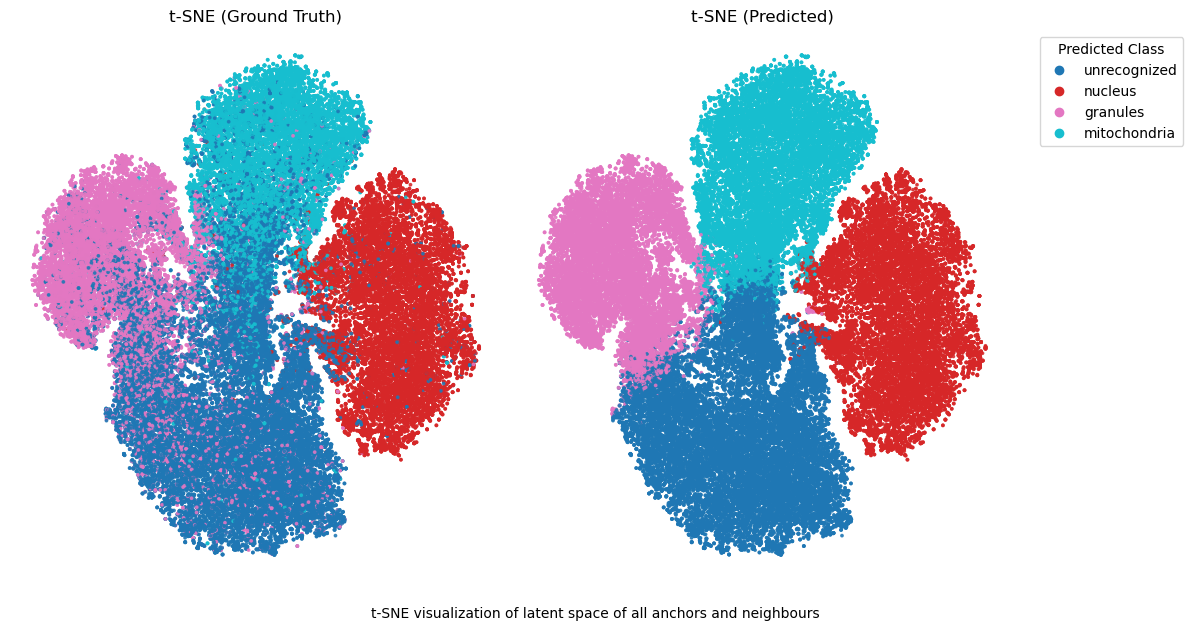

In [5]:
Y = embedding_train  # (N, 2)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=labels, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all anchors and neighbours", 
         ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.show()


--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 1.70 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.15 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=835.58 for 250 iterations...
Iteration   50, KL divergence 4.0478, 50 iterations in 0.6721 sec
Iteration  100, KL divergence 3.9911, 50 iterations in 0.6826 sec
Iteration  150, KL divergence 3.9686, 50 iterations in 0.6836 sec
Iteration  200, KL divergence 3.9610, 50 iterations in 0.6734 sec
Iteration  250, KL divergence 3.9572, 50 iterations in 0.6670 sec
   --> Time elapsed: 3.38 seconds
===> Running optimization with exaggeration=1.

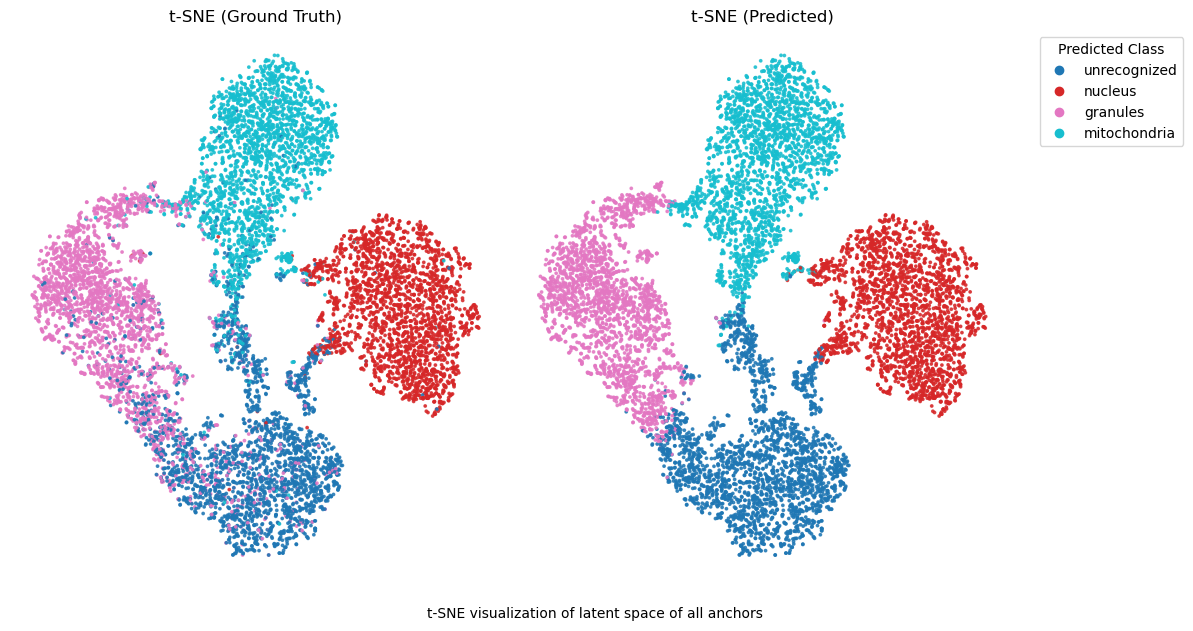

In [6]:
%time Y = tsne.fit(Z_anchors)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all anchors", 
         ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 16.09 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 1.00 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.02 seconds
===> Running optimization with exaggeration=12.00, lr=5849.08 for 250 iterations...
Iteration   50, KL divergence 5.8534, 50 iterations in 2.6117 sec
Iteration  100, KL divergence 5.6936, 50 iterations in 2.6233 sec
Iteration  150, KL divergence 5.6553, 50 iterations in 2.7882 sec
Iteration  200, KL divergence 5.6403, 50 iterations in 2.7159 sec
Iteration  250, KL divergence 5.6336, 50 iterations in 2.9656 sec
   --> Time elapsed: 13.71 seconds
===> Running optimization with exaggeration

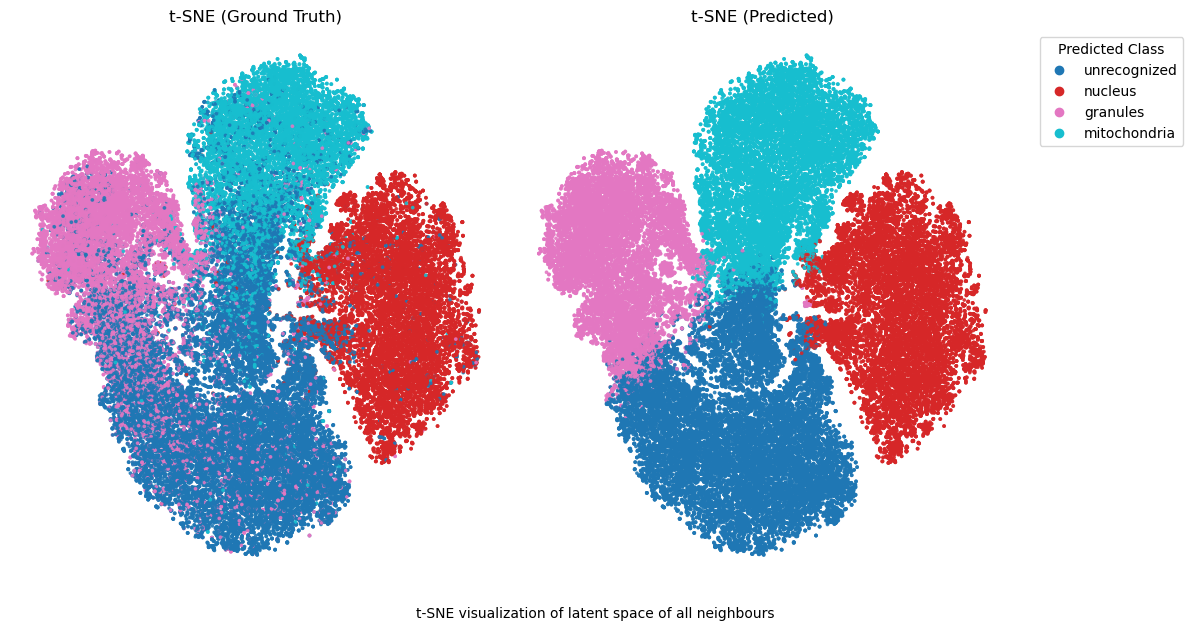

In [8]:
%time Y = tsne.fit(Z_neighbours)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all neighbours", 
         ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
i = 100
df[df['pred_label']!=df['label']].iloc[8*i:8*(i+1)]

,anchor_id,name,z,y,x,label,neighbor_index,pi,latent,pred_label
0,0,high_c1,564,492,239,0,0,"[0.07352841, 0.02248963, 0.07229102, 0.83169097]","[-0.016833726, -0.019979635, -0.0005386804, 0....",3
1,0,high_c1,564,490,236,0,1,"[0.07590519, 0.010969708, 0.048428576, 0.86469...","[-0.017771026, -0.018628268, 0.001536062, 0.03...",3
2,0,high_c1,564,489,233,0,2,"[0.106932424, 0.01186806, 0.03791273, 0.8432868]","[-0.020297896, -0.0171414, 0.0014506405, 0.036...",3
3,0,high_c1,564,485,246,0,3,"[0.12520511, 0.1723432, 0.122508086, 0.5799436]","[-0.02082737, -0.022710996, -0.0016658435, 0.0...",3
4,0,high_c1,564,495,230,0,4,"[0.21150593, 0.0031452563, 0.058973055, 0.7263...","[-0.017306864, -0.018594839, 0.0018965538, 0.0...",3
...,...,...,...,...,...,...,...,...,...,...
80181,10022,high_c3,558,604,549,2,5,"[0.6323818, 0.00023341327, 0.36030766, 0.00707...","[-0.008906528, -0.02167532, 0.0036450685, 0.02...",0
80204,10025,high_c3,558,252,482,0,4,"[0.43732, 0.00021172636, 0.5623041, 0.0001642003]","[-0.013377075, -0.014702387, 0.010014876, 0.02...",2
80206,10025,high_c3,558,258,480,0,6,"[0.07448935, 0.0005003697, 0.92494506, 6.51152...","[-0.013459944, -0.013892921, 0.008570627, 0.01...",2
80210,10026,high_c3,558,202,544,0,2,"[0.22417581, 0.00035324012, 0.006219926, 0.769...","[-0.0071306773, -0.017692043, 0.005359745, 0.0...",3


In [9]:
def plot_ld_pd_one_anchor(class_label):

    # find reference anchor
    ref_label = class_label
    ref = df[(df['label']==class_label) & (df['neighbor_index']==0)].iloc[0]
    ref_anchor_id = ref['anchor_id']
    ref_name = ref['name']
    ref_pos = np.array([ref['z'], ref['y'], ref['x']]).astype(float)
    ref_latent = ref['latent']
    assert ref_label == ref['label'], "Reference label does not match class label"
    print(f"Reference anchor from class {label_names[class_label]} at {ref_pos}")
    
    neighbors = df[df['anchor_id'] == ref_anchor_id]
    others    = df[(df['neighbor_index']==0) & (df['name']==ref_name) & (df['anchor_id']!=ref_anchor_id)]
    subset = pd.concat([neighbors, others], ignore_index=True)
    
    results = []

    for _, n in neighbors.iterrows():
        n_vec = n['latent']
        n_id  = n['anchor_id']  # original anchor id

        # compute distances to all anchors in 'others'
        dists = others['latent'].apply(lambda a_vec: norm(n_vec - a_vec)).values

        # index of closest anchor
        closest_idx = dists.argmin()
        closest_anchor = others.iloc[closest_idx]

        # get its own anchor latent
        own_anchor_vec = df[(df['anchor_id']==n_id) & (df['neighbor_index']==0)]['latent'].values[0]
        dist_to_own = norm(n_vec - own_anchor_vec)
        dist_to_closest = dists[closest_idx]

        results.append({
            "neighbor_coords": (n['z'], n['y'], n['x']),
            "neighbor_label": n['label'],
            "closest_anchor_id": closest_anchor['anchor_id'],
            "closest_anchor_label": closest_anchor['label'],
            "dist_to_original": dist_to_own,
            "dist_to_closest": dist_to_closest,
            "closer_to_own": dist_to_own < dist_to_closest
        })

    res_df = pd.DataFrame(results)

    # quick summary: what % of neighbors are closer to their own anchor
    print(res_df['closer_to_own'].value_counts(normalize=True))
    print(res_df)

    pixel_dists = []
    latent_dists = []
    gt = []
    is_neighbor = []

    for _, r in subset.iterrows():
        pos_r  = np.array([r['z'], r['y'], r['x']], float)
        latent_r = r['latent']
        pixel_dists.append(norm(pos_r - ref_pos))
        latent_dists.append(norm(latent_r - ref_latent))
        gt.append(r['label'])
        is_neighbor.append(r['neighbor_index'] != 0)
        if is_neighbor[-1]:
            print(f"Neighbor: {r['neighbor_index']} at {pos_r} with label {r['label']}")

    _, (ax_scatter, ax_violin) = plt.subplots(
        nrows=1, ncols=2,
        gridspec_kw={'width_ratios':[3,1]},
        figsize=(9,5),
        sharey=True
    )
    
    # main scatter with colormap
    sc = ax_scatter.scatter(pixel_dists, latent_dists, c=gt, s=30, cmap='tab10', edgecolors='none')

    # add black edged markers for neighbors
    for x,y,is_nbr,c in zip(pixel_dists, latent_dists, is_neighbor, gt):
        if is_nbr:
            ax_scatter.scatter(x, y, facecolors='none', edgecolors='k', s=50, linewidths=1)
  
    handles = [plt.Line2D([],[],marker='o',linestyle='', color=sc.cmap(sc.norm(i)), label=label_names[i]) for i in range(4)]
    ax_scatter.legend(handles=handles, title='Class', bbox_to_anchor=(1.05,1), loc='upper left')
    ax_scatter.set_xlabel("Pixel distance (3D)")
    ax_scatter.set_ylabel("Latent distance")
    ax_scatter.set_title(f"Anchor from class {label_names[class_label]}")

    # Violin plot
    xs = []   # latent distances grouped by class
    for lab in sorted(set(gt)):
        xs.append([ld for ld,cl in zip(latent_dists,gt) if cl==lab])
    parts = ax_violin.violinplot(xs, positions=range(len(xs)), showmedians=True)

    # match colors to scatter
    for i, pc in enumerate(parts['bodies']):
        color = sc.cmap(sc.norm(sorted(set(gt))[i]))
        pc.set_facecolor(color)
        pc.set_alpha(0.9)

    ax_violin.set_xticks(range(len(xs)))
    ax_violin.set_xlabel('Class')

    plt.tight_layout()
    plt.show()


Reference anchor from class unrecognized at [564. 492. 239.]
closer_to_own
True     0.5
False    0.5
Name: proportion, dtype: float64
   neighbor_coords  neighbor_label  closest_anchor_id  closest_anchor_label  \
0  (564, 492, 239)               0                389                     3   
1  (564, 490, 236)               0               1317                     0   
2  (564, 489, 233)               0               1317                     0   
3  (564, 485, 246)               0               1559                     0   
4  (564, 495, 230)               0                334                     3   
5  (564, 488, 236)               0               1317                     0   
6  (564, 499, 242)               0               3289                     2   
7  (564, 489, 243)               0               1559                     0   

   dist_to_original  dist_to_closest  closer_to_own  
0          0.000000         0.162842           True  
1          0.086698         0.106836          

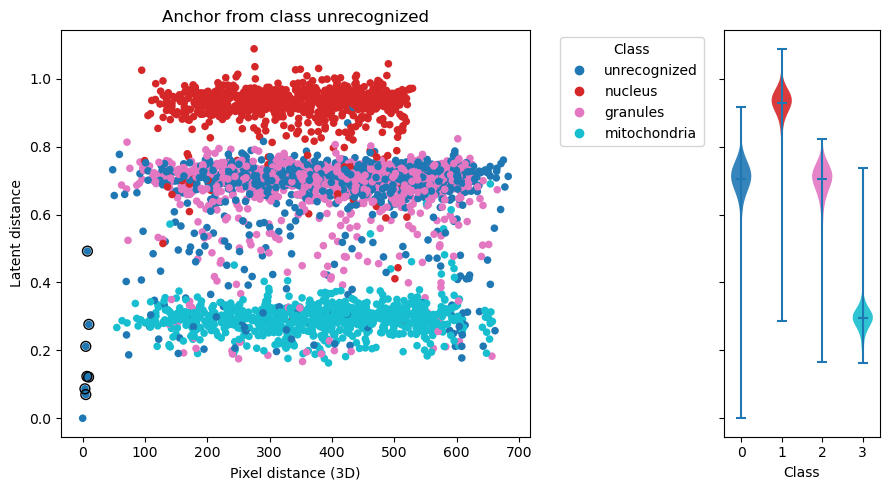

Reference anchor from class nucleus at [600. 318. 408.]
closer_to_own
True     0.5
False    0.5
Name: proportion, dtype: float64
   neighbor_coords  neighbor_label  closest_anchor_id  closest_anchor_label  \
0  (600, 318, 408)               1                 23                     1   
1  (600, 309, 411)               1               1657                     1   
2  (600, 325, 404)               1                 23                     1   
3  (600, 319, 411)               1               3148                     1   
4  (600, 310, 408)               1                984                     1   
5  (600, 327, 408)               1               2955                     1   
6  (600, 311, 407)               1                753                     1   
7  (600, 324, 407)               1                 23                     1   

   dist_to_original  dist_to_closest  closer_to_own  
0          0.000000         0.050728           True  
1          0.057987         0.063871           True

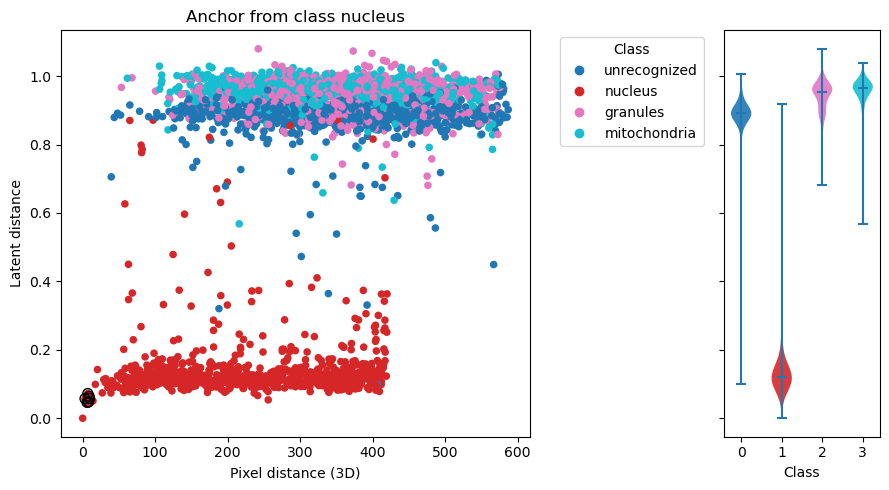

Reference anchor from class granules at [564. 350. 249.]
closer_to_own
False    0.625
True     0.375
Name: proportion, dtype: float64
   neighbor_coords  neighbor_label  closest_anchor_id  closest_anchor_label  \
0  (564, 350, 249)               2               1882                     2   
1  (564, 353, 249)               2               2428                     2   
2  (564, 348, 243)               2               2203                     2   
3  (564, 346, 249)               2               2852                     2   
4  (564, 352, 242)               2               1887                     2   
5  (564, 351, 250)               2               2428                     2   
6  (564, 359, 247)               0               1012                     0   
7  (564, 341, 253)               2               1950                     2   

   dist_to_original  dist_to_closest  closer_to_own  
0          0.000000         0.043004           True  
1          0.056968         0.056863          

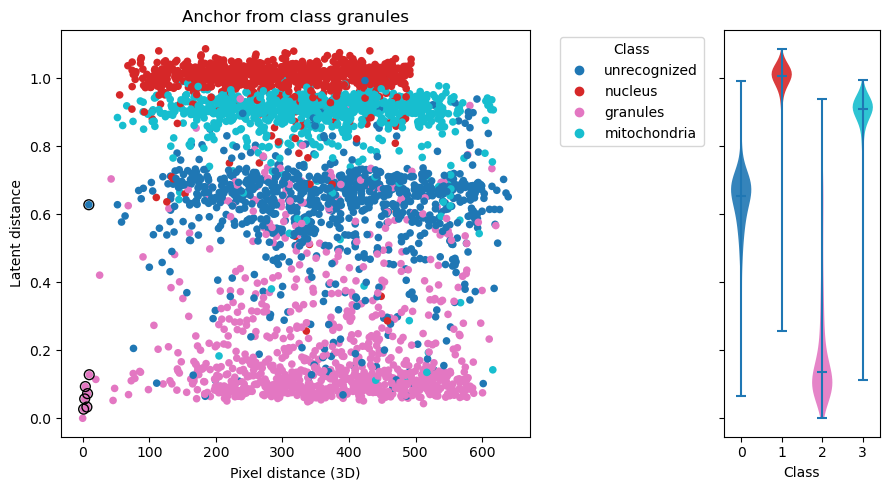

Reference anchor from class mitochondria at [564. 453. 352.]
closer_to_own
False    0.75
True     0.25
Name: proportion, dtype: float64
   neighbor_coords  neighbor_label  closest_anchor_id  closest_anchor_label  \
0  (564, 453, 352)               3               1815                     2   
1  (564, 446, 354)               0                993                     0   
2  (564, 462, 353)               3               2152                     3   
3  (564, 461, 348)               3               2152                     3   
4  (564, 450, 351)               3                593                     3   
5  (564, 445, 349)               0                144                     0   
6  (564, 451, 356)               3               3280                     2   
7  (564, 448, 353)               3               2215                     2   

   dist_to_original  dist_to_closest  closer_to_own  
0          0.000000         0.096470           True  
1          0.354547         0.148792        

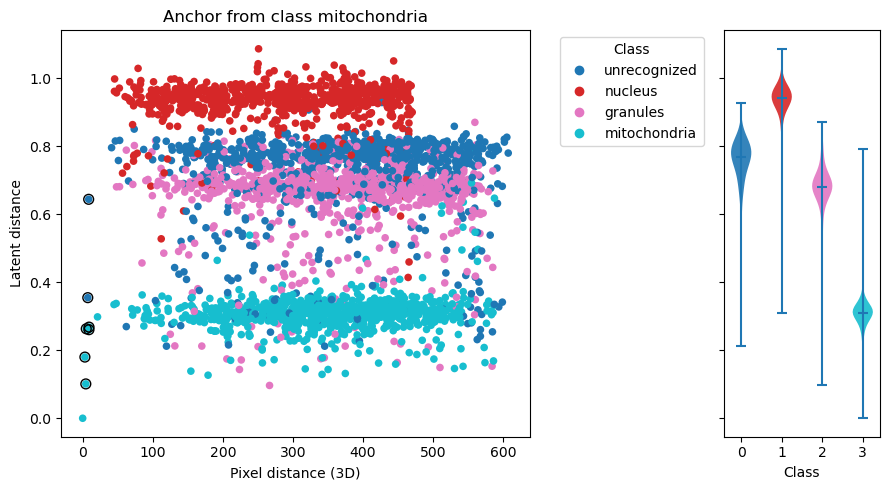

In [10]:
for class_label in range(4):
    plot_ld_pd_one_anchor(class_label)

In [25]:
def plot_ld_pd_one_anchor(class_label):
    df = pd.read_pickle("dataset.pkl")

    # --- reference anchor
    ref = df[(df['label']==class_label) & (df['neighbor_index']==0)].iloc[0]
    ref_anchor_id = ref['anchor_id']
    ref_name = ref['name']
    ref_pos = np.array([ref['z'], ref['y'], ref['x']], float)
    ref_latent = ref['latent']

    neighbors = df[df['anchor_id'] == ref_anchor_id].copy()
    others    = df[(df['neighbor_index']==0) & (df['name']==ref_name) & (df['anchor_id']!=ref_anchor_id)]
    subset = pd.concat([neighbors, others], ignore_index=True)

    # --- predicted labels for neighbors
    neighbors["pred_label"] = neighbors["pi"].apply(lambda p: np.argmax(p))

    # --- distances
    pixel_dists, latent_dists, gt, is_neighbor = [], [], [], []
    for _, r in subset.iterrows():
        pos_r  = np.array([r['z'], r['y'], r['x']], float)
        latent_r = r['latent']
        pixel_dists.append(norm(pos_r - ref_pos))
        latent_dists.append(norm(latent_r - ref_latent))
        gt.append(r['label'])
        is_neighbor.append(r['neighbor_index'] != 0)

    # --- plotting
    fig, (ax_sc, ax_v) = plt.subplots(
        1, 2, gridspec_kw={'width_ratios':[3,1]}, figsize=(9,5), sharey=True
    )

    # scatter with gt coloring
    sc = ax_sc.scatter(pixel_dists, latent_dists, c=gt, s=30, cmap="tab10", edgecolors="none")
    for x,y,nbr in zip(pixel_dists, latent_dists, is_neighbor):
        if nbr:
            ax_sc.scatter(x, y, facecolors="none", edgecolors="k", s=50, linewidths=1)

    label_names = {0:'unrecognized',1:'nucleus',2:'granules',3:'mitochondria'}
    handles = [plt.Line2D([],[],marker='o',linestyle='', color=sc.cmap(sc.norm(i)), label=label_names[i]) for i in range(4)]
    ax_sc.legend(handles=handles, title='GT Class', bbox_to_anchor=(1.05,1), loc='upper left')
    ax_sc.set_xlabel("Pixel distance (3D)")
    ax_sc.set_ylabel("Latent distance")
    ax_sc.set_title(f"Anchor from class {label_names[class_label]} ({ref_name})")

    # --- violin for neighbors grouped by predicted label
    xs = []
    uniq_pred = sorted(neighbors["pred_label"].unique())
    for lab in uniq_pred:
        # grab latent dists only for neighbors with this predicted label
        vals = []
        for idx, r in neighbors.iterrows():
            pos_r = np.array([r['z'], r['y'], r['x']], float)
            vals.append(norm(r['latent'] - ref_latent))
        xs.append([v for v,r in zip(vals, neighbors["pred_label"]) if r==lab])

    parts = ax_v.violinplot(xs, positions=range(len(xs)), showmedians=True)

    for i,pc in enumerate(parts['bodies']):
        color = sc.cmap(sc.norm(uniq_pred[i]))
        pc.set_facecolor(color)
        pc.set_alpha(0.9)

    ax_v.set_xticks(range(len(xs)))
    ax_v.set_xticklabels([label_names[lab] for lab in uniq_pred], rotation=45)
    ax_v.set_xlabel("Predicted class (neighbors)")

    plt.tight_layout()
    plt.show()


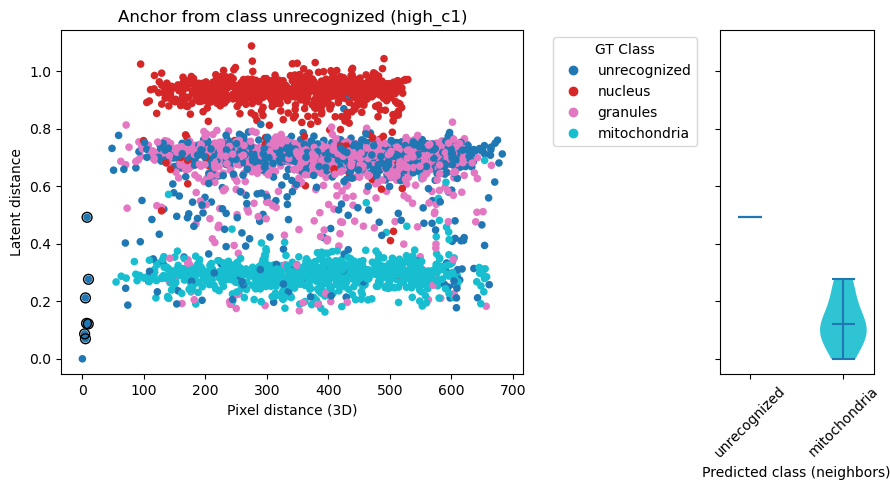

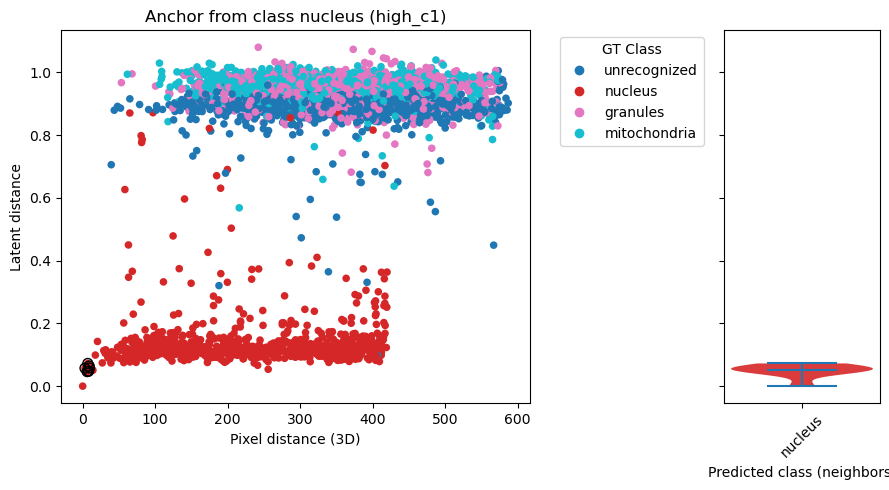

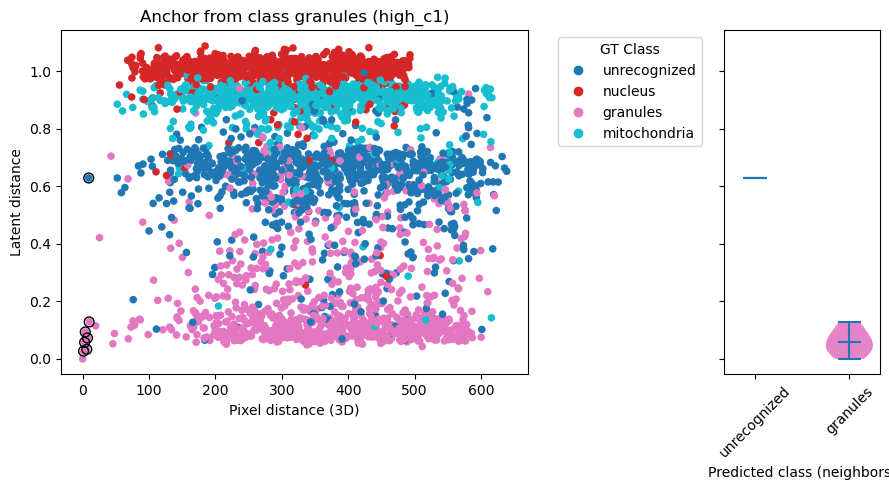

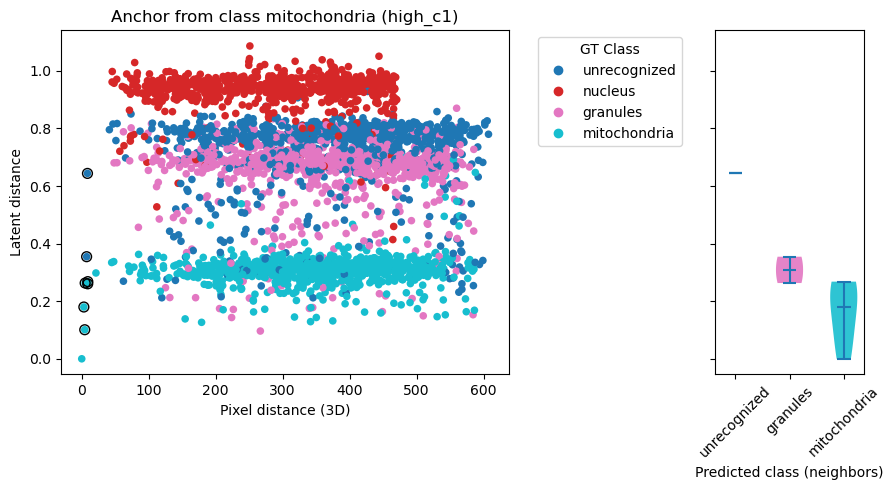

In [26]:
for class_label in range(4):
    plot_ld_pd_one_anchor(class_label)